In [1]:
# import required packages
import warnings
warnings.filterwarnings('ignore')

import numpy as np
from matplotlib import pyplot as plt
from matplotlib import colors as mpc
from sklearn.mixture import GaussianMixture
import pandas as pd
import math
import seaborn as sns; sns.set()
from sklearn.metrics import r2_score 
# from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
# from sklearn.model_selection import KFold
from sklearn import linear_model
# from sklearn.ensemble import RandomForestRegressor
from gmr import GMM #https://alexanderfabisch.github.io/gmr/gmm.html#gmr.gmm.GMM.predict

from IPython.display import clear_output

%load_ext autoreload
%autoreload 
%matplotlib inline

### Define functions for analysis 

In [2]:
# define functions for model evaluation
def n_bias(estimated, true):
    estimated_ = estimated.reshape(estimated.shape[0])
    
    true_ = true.reshape(true.shape[0])
    return np.sum(np.subtract(estimated_, true_))/estimated_.shape[0]

def cvMAE(estimated, true):
    estimated_ = estimated.reshape(estimated.shape[0])
    true_ = true.reshape(true.shape[0])
    return np.sum(abs(np.subtract(estimated_, true_) - n_bias(estimated_, true)))/np.sum(true_)

def mnbias(estimated, true):
    estimated_ = estimated.reshape(estimated.shape[0])
    true_ = true.reshape(true.shape[0])
    return np.sum(np.subtract(estimated_, true_))/np.sum(true_)

def nmae(estimated, true):
    estimated_ = estimated.reshape(estimated.shape[0])
    true_ = true.reshape(true.shape[0])
    return np.sum(np.abs(np.subtract(estimated_, true_)))/np.sum(true_)

## Load day blocked train/test split for ML

In [3]:
# import data
# INSERT PATH TO FILE HERE
path = "/Users/lewiswhite/CHAP_columbia/QuantAQ_ghana/data/calibration/mod_grimm_day_block_split_20260315.csv"
model_data_dayblock = pd.read_csv(path, header = 0, index_col = 0)

model_data_dayblock.head()

,monitor,date_hour,date,hour,season,sin_hour,cos_hour,season_binary,mod_pm25,mod_pm1,mod_pm10,mod_temp,mod_rh,grimm_pm25,split_day_block
row_id,,,,,,,,,,,,,,,
1,MOD-PM-00884,2025-08-11T15:00:00Z,2025-08-11,15,Not Harmattan,-0.707107,-7.071068e-01,0,28.345801,27.432117,27.278433,29.274333,63.610667,12.753846,train
2,MOD-PM-00884,2025-08-11T16:00:00Z,2025-08-11,16,Not Harmattan,-0.866025,-5.000000e-01,0,26.151898,25.329228,26.324786,29.145333,66.256333,14.813333,train
3,MOD-PM-00884,2025-08-11T17:00:00Z,2025-08-11,17,Not Harmattan,-0.965926,-2.588190e-01,0,54.440715,51.968724,47.903003,29.045472,66.595283,13.878333,train
4,MOD-PM-00884,2025-08-11T18:00:00Z,2025-08-11,18,Not Harmattan,-1.000000,-1.836970e-16,0,38.984314,37.306635,35.711713,28.003400,69.538600,13.393333,train
5,MOD-PM-00884,2025-08-11T19:00:00Z,2025-08-11,19,Not Harmattan,-0.965926,2.588190e-01,0,30.793365,29.665518,29.383296,27.130000,71.385424,22.465000,train


In [4]:
train_ = model_data_dayblock[model_data_dayblock['split_day_block'] == 'train'].copy()
test_  = model_data_dayblock[model_data_dayblock['split_day_block'] == 'test'].copy()

train_ = train_[['mod_pm25', 'mod_temp', 'mod_rh', 'grimm_pm25']]
test_  = test_[['mod_pm25', 'mod_temp', 'mod_rh', 'grimm_pm25']]

train_ = train_.dropna()
test_ = test_.dropna()

model_data_dayblock = model_data_dayblock[['mod_pm25', 'mod_temp', 'mod_rh', 'grimm_pm25']].dropna()

print(train_.shape)
print(test_.shape)

(2413, 4)
(578, 4)


## GMR 1: GMR using PM2.5 + temperature + RH

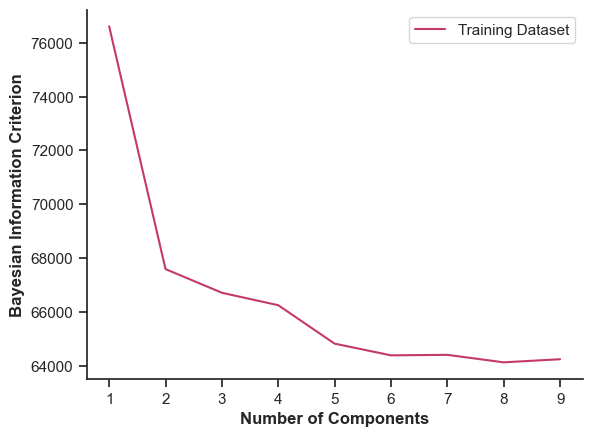

In [5]:
# select models with lowest BIC/AIC
n_components = np.arange(1, 10)
models_train = [GaussianMixture(n, covariance_type = 'full', random_state = 2).fit(train_) for n in n_components]

sns.set_style("ticks", {"xtick.major.size": 7, "ytick.major.size": 7})

plt.plot(n_components, [m.bic(train_) for m in models_train], color = "#C33969", label = 'Training Dataset')
plt.legend(loc = 'upper right')
plt.xlabel('Number of Components', fontweight = 'bold')
plt.ylabel('Bayesian Information Criterion', fontweight = 'bold')

sns.despine()
plt.show()

In [6]:
bic_values = [m.bic(train_) for m in models_train]
best_n = n_components[np.argmin(bic_values)]

print("Best number of components:", 5) ## hard coded 5 instead of using best_n because marginal improvements in BIC

# build GMM with components as suggested by BIC
gmm = GMM(n_components=5, random_state=11)
gmm.from_samples(train_.to_numpy())

# regress test values
Y = gmm.predict(
    np.array([0, 1, 2]),
    test_[["mod_pm25", "mod_temp", "mod_rh"]].to_numpy()
)

y_true = test_["grimm_pm25"].to_numpy()
y_pred = Y.ravel()


rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print('R2: ', r2_score(y_true, y_pred))
print('MAE: ', mean_absolute_error(y_true, y_pred))
print('RMSE: ', rmse)
print('Bias: ', n_bias(y_pred, y_true))
print('Bias Corrected Mean Normalized Absolute Error: ', cvMAE(y_pred, y_true))
print('Mean Normalized Bias: ', mnbias(y_pred, y_true))

Best number of components: 5
R2:  0.673546331837128
MAE:  4.055278794394779
RMSE:  6.797996746427194
Bias:  0.17339279992147302
Bias Corrected Mean Normalized Absolute Error:  0.23675796709697483
Mean Normalized Bias:  0.010165766003936035


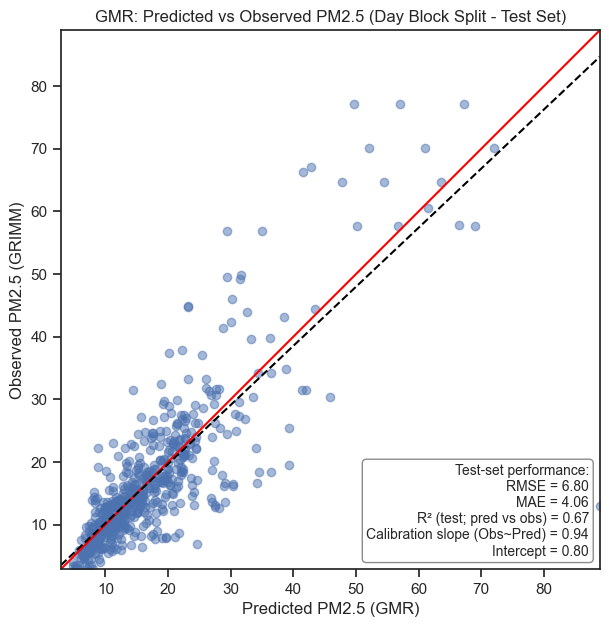

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression

# Build test results dataframe
test_results = test_.copy()
test_results["pred_gmr"] = y_pred  # assumes y_pred is your GMR prediction from the test set

# Metrics
rmse_val = np.sqrt(mean_squared_error(test_results["grimm_pm25"], test_results["pred_gmr"]))
mae_val = mean_absolute_error(test_results["grimm_pm25"], test_results["pred_gmr"])
rsq_val = r2_score(test_results["grimm_pm25"], test_results["pred_gmr"])

# Calibration: observed ~ predicted
cal_model = LinearRegression()
X_cal = test_results[["pred_gmr"]]
y_cal = test_results["grimm_pm25"]
cal_model.fit(X_cal, y_cal)

cal_int = cal_model.intercept_
cal_slope = cal_model.coef_[0]

# Shared axis limits
lims = [
    min(test_results["grimm_pm25"].min(), test_results["pred_gmr"].min()),
    max(test_results["grimm_pm25"].max(), test_results["pred_gmr"].max())
]

# Plot
plt.figure(figsize=(7, 7))

# points
plt.scatter(
    test_results["pred_gmr"],
    test_results["grimm_pm25"],
    alpha=0.5
)

# 1:1 line
plt.plot(lims, lims, color="red")

# fitted calibration line
x_line = np.linspace(lims[0], lims[1], 200)
y_line = cal_int + cal_slope * x_line
plt.plot(x_line, y_line, linestyle="dashed", color="black")

# equal axes
plt.xlim(lims)
plt.ylim(lims)
plt.gca().set_aspect('equal', adjustable='box')

# labels and title
plt.title("GMR: Predicted vs Observed PM2.5 (Day Block Split - Test Set)")
plt.xlabel("Predicted PM2.5 (GMR)")
plt.ylabel("Observed PM2.5 (GRIMM)")

# annotation box
caption_text = (
    f"Test-set performance:\n"
    f"RMSE = {rmse_val:.2f}\n"
    f"MAE = {mae_val:.2f}\n"
    f"R² (test; pred vs obs) = {rsq_val:.2f}\n"
    f"Calibration slope (Obs~Pred) = {cal_slope:.2f}\n"
    f"Intercept = {cal_int:.2f}"
)

plt.text(
    0.98, 0.02,
    caption_text,
    transform=plt.gca().transAxes,
    ha="right",
    va="bottom",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.9)
)

plt.show()

## Missing input analysis

In [8]:
# Missing RH
Y_noRH = gmm.predict(np.array([0, 1]), test_[["mod_pm25", "mod_temp"]].to_numpy())
y_pred = Y_noRH[:, 1]
y_true = test_["grimm_pm25"].to_numpy()

print('conditional GMR prediction with missing RH')
print('R2: ', r2_score(y_true, y_pred))
print('MAE: ', mean_absolute_error(y_true, y_pred))
print('Bias: ', n_bias(y_pred, y_true))
print('cvMAE: ', cvMAE(y_pred, y_true))
print('MNB: ', mnbias(y_pred, y_true))


# Missing temperature
Y_notemp = gmm.predict(np.array([0, 2]), test_[["mod_pm25", "mod_rh"]].to_numpy())
y_pred = Y_notemp[:, 1]

print('\nconditional GMR prediction wit missing temperature')
print('R2: ', r2_score(y_true, y_pred))
print('MAE: ', mean_absolute_error(y_true, y_pred))
print('Bias: ', n_bias(y_pred, y_true))
print('cvMAE: ', cvMAE(y_pred, y_true))
print('MNB: ', mnbias(y_pred, y_true))


# Missing temperature and RH
Y_justMOD = gmm.predict(np.array([0]), test_[["mod_pm25"]].to_numpy())
y_pred = Y_justMOD[:, 2]

print('\nconditional GMR prediction with missing temperature and RH')
print('R2: ', r2_score(y_true, y_pred))
print('MAE: ', mean_absolute_error(y_true, y_pred))
print('Bias: ', n_bias(y_pred, y_true))
print('cvMAE: ', cvMAE(y_pred, y_true))
print('MNB: ', mnbias(y_pred, y_true))

conditional GMR prediction with missing RH
R2:  0.6201456929075015
MAE:  4.2663490304756415
Bias:  0.6207961146703259
cvMAE:  0.2463828719967061
MNB:  0.036396367327531896

conditional GMR prediction wit missing temperature
R2:  0.6340209438156938
MAE:  4.1647982360738744
Bias:  0.2411853343985725
cvMAE:  0.2427156886626739
MNB:  0.01414034304877337

conditional GMR prediction with missing temperature and RH
R2:  0.6093307034806091
MAE:  4.617931571439519
Bias:  0.46787081487881277
cvMAE:  0.26906442221298865
MNB:  0.02743058089080357


## GMR Figures

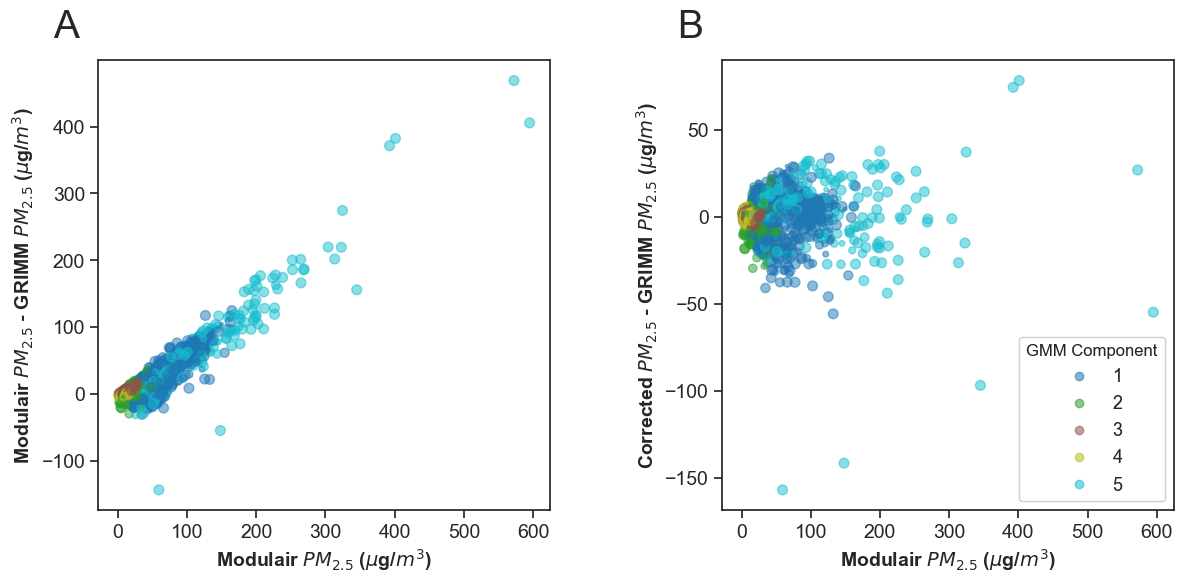

In [9]:
# GMR Figures

# use cleaned modeling data so dimensions match what gmm expects
plot_data = train_[['mod_pm25', 'mod_temp', 'mod_rh', 'grimm_pm25']].dropna().copy()

# get array of responsibilities based on ORIGINAL GMM and not GMR
# each row gives probabilities of belonging to each mixture component
probs = gmm.to_responsibilities(plot_data.to_numpy())
labels = np.argmax(probs, axis=1)

# create size object to visualize responsibilities more easily
size = 50 * probs.max(1) ** 3
legend_values = labels + 1

# get array of raw biases to plot
bias = plot_data["mod_pm25"].to_numpy() - plot_data["grimm_pm25"].to_numpy()

# regress entire data set
Y2 = gmm.predict(
    np.array([0, 1, 2]),
    plot_data[["mod_pm25", "mod_temp", "mod_rh"]].to_numpy()
).ravel()

modelbias = Y2 - plot_data["grimm_pm25"].to_numpy()

# set color map
colors = plt.cm.get_cmap('tab10', best_n)

sns.set_style("ticks", {"xtick.major.size": 7, "ytick.major.size": 7})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.scatter(
    plot_data["mod_pm25"],
    bias,
    c=legend_values,
    cmap=colors,
    s=size,
    alpha=0.5
)
ax1.tick_params(axis='x', labelsize=14)
ax1.tick_params(axis='y', labelsize=14)
ax1.set_xlabel('Modulair $PM_{2.5}$ ($\\mu$g/$m^3$)', fontweight='bold', fontsize=14)
ax1.set_ylabel('Modulair $PM_{2.5}$ - GRIMM $PM_{2.5}$ ($\\mu$g/$m^3$)', fontweight='bold', fontsize=14)
ax1.text(-0.1, 1.05, "A", transform=ax1.transAxes, size=28)

scatterb = ax2.scatter(
    plot_data["mod_pm25"],
    modelbias,
    c=legend_values,
    cmap=colors,
    s=size,
    alpha=0.5
)
ax2.tick_params(axis='x', labelsize=14)
ax2.tick_params(axis='y', labelsize=14)
ax2.set_xlabel('Modulair $PM_{2.5}$ ($\\mu$g/$m^3$)', fontweight='bold', fontsize=14)
ax2.set_ylabel('Corrected $PM_{2.5}$ - GRIMM $PM_{2.5}$ ($\\mu$g/$m^3$)', fontweight='bold', fontsize=14)
ax2.text(-0.1, 1.05, "B", transform=ax2.transAxes, size=28)

legend2 = ax2.legend(
    *scatterb.legend_elements(),
    loc='best',
    title="GMM Component",
    fontsize=13
)
ax2.add_artist(legend2)
plt.setp(legend2.get_title(), fontsize=12)

fig.tight_layout(w_pad=5)
plt.show()

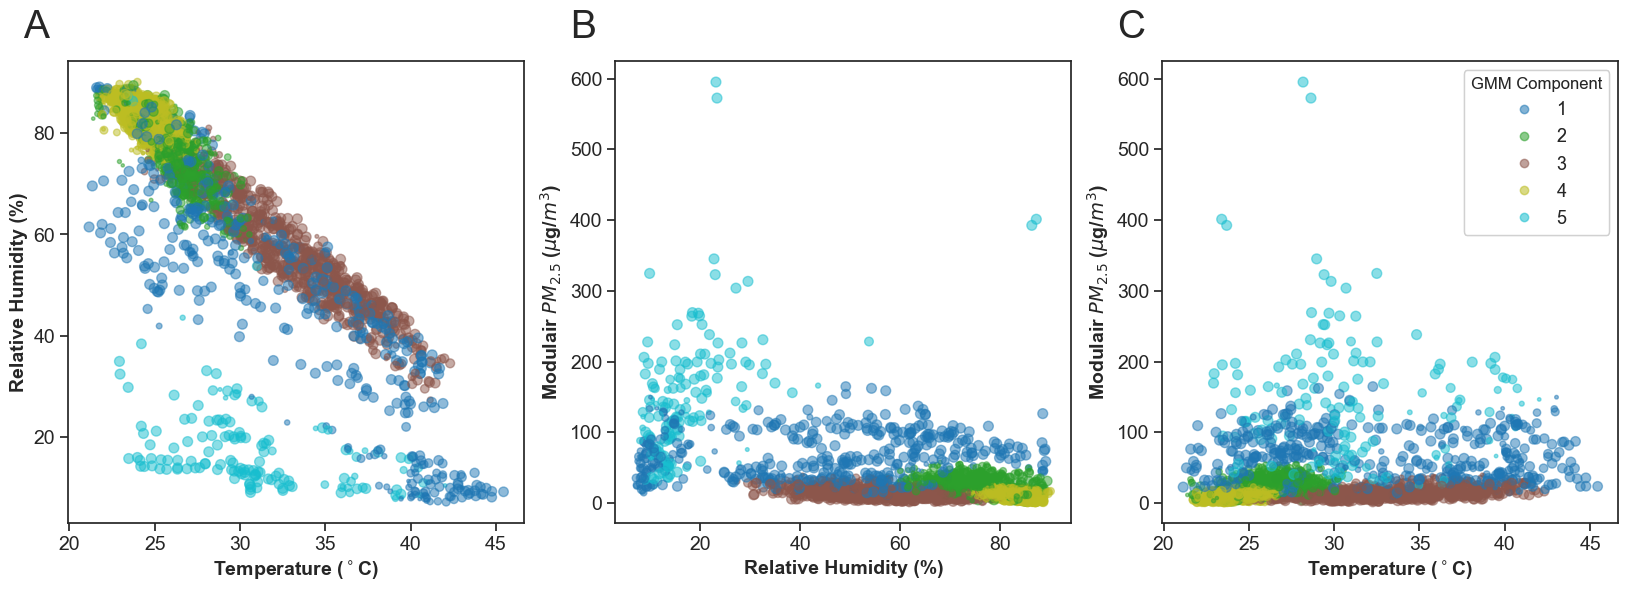

In [10]:

sns.set_style("ticks", {"xtick.major.size": 7, "ytick.major.size": 7})
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

ax1.scatter(
    plot_data["mod_temp"],
    plot_data["mod_rh"],
    c=legend_values,
    cmap=colors,
    s=size,
    alpha=0.5
)
ax1.tick_params(axis='x', labelsize=14)
ax1.tick_params(axis='y', labelsize=14)
ax1.set_xlabel('Temperature ($^\\circ$C)', fontweight='bold', fontsize=14)
ax1.set_ylabel('Relative Humidity (%)', fontweight='bold', fontsize=14)
ax1.text(-0.1, 1.05, "A", transform=ax1.transAxes, size=28)

ax2.scatter(
    plot_data["mod_rh"],
    plot_data["mod_pm25"],
    c=legend_values,
    cmap=colors,
    s=size,
    alpha=0.5
)
ax2.tick_params(axis='x', labelsize=14)
ax2.tick_params(axis='y', labelsize=14)
ax2.set_ylabel('Modulair $PM_{2.5}$ ($\\mu$g/$m^3$)', fontweight='bold', fontsize=14)
ax2.set_xlabel('Relative Humidity (%)', fontweight='bold', fontsize=14)
ax2.text(-0.1, 1.05, "B", transform=ax2.transAxes, size=28)

scatter3 = ax3.scatter(
    plot_data["mod_temp"],
    plot_data["mod_pm25"],
    c=legend_values,
    cmap=colors,
    s=size,
    alpha=0.5
)
ax3.tick_params(axis='x', labelsize=14)
ax3.tick_params(axis='y', labelsize=14)
ax3.set_ylabel('Modulair $PM_{2.5}$ ($\\mu$g/$m^3$)', fontweight='bold', fontsize=14)
ax3.set_xlabel('Temperature ($^\\circ$C)', fontweight='bold', fontsize=14)
ax3.text(-0.1, 1.05, "C", transform=ax3.transAxes, size=28)

legend3 = ax3.legend(
    *scatter3.legend_elements(),
    loc='best',
    title="GMM Component",
    fontsize=13
)
ax3.add_artist(legend3)
plt.setp(legend3.get_title(), fontsize=12)

plt.show()

## GMR 2: GMR using PM2.5 + temperature + RH + cyclical hour + seasons

### Day block train/test split

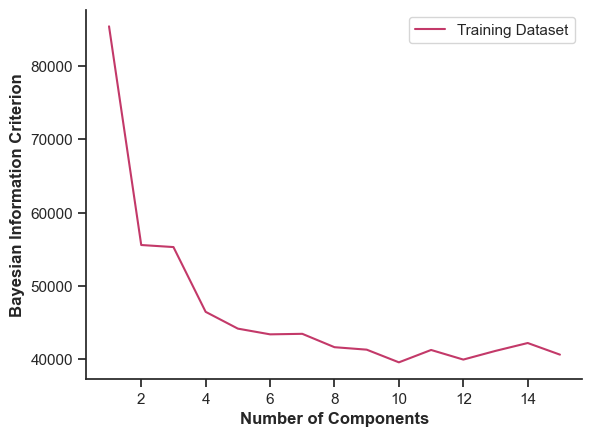

In [11]:
# import data
path = "/Users/lewiswhite/CHAP_columbia/QuantAQ_ghana/data/calibration/mod_grimm_day_block_split_20260315.csv"
model_data_dayblock = pd.read_csv(path, header=0, index_col=0)

# make sure season is numeric for GMM
model_data_dayblock["season_binary"] = np.where(model_data_dayblock["season"] == "Harmattan", 1, 0)

train_ = model_data_dayblock[model_data_dayblock["split_day_block"] == "train"].copy()
test_  = model_data_dayblock[model_data_dayblock["split_day_block"] == "test"].copy()

train_ = train_[["mod_pm25", "mod_temp", "mod_rh", "sin_hour", "cos_hour", "season_binary", "grimm_pm25"]]
test_  = test_[["mod_pm25", "mod_temp", "mod_rh", "sin_hour", "cos_hour", "season_binary", "grimm_pm25"]]

train_ = train_.dropna()
test_ = test_.dropna()

model_data_dayblock_clean = model_data_dayblock[["mod_pm25", "mod_temp", "mod_rh", "sin_hour", "cos_hour", "season_binary", "grimm_pm25"]].dropna()

# select models with lowest BIC/AIC
n_components = np.arange(1, 16)
models_train = [
    GaussianMixture(n, covariance_type="full", random_state=2).fit(train_)
    for n in n_components
]

sns.set_style("ticks", {"xtick.major.size": 7, "ytick.major.size": 7})

plt.plot(
    n_components,
    [m.bic(train_) for m in models_train],
    color="#C33969",
    label="Training Dataset"
)
plt.legend(loc="upper right")
plt.xlabel("Number of Components", fontweight="bold")
plt.ylabel("Bayesian Information Criterion", fontweight="bold")
sns.despine()
plt.show()

In [12]:
bic_values = [m.bic(train_) for m in models_train]
best_n = 4 # hard code based on plot

print("Best number of components:", best_n)

# build GMM with components as suggested by BIC
gmm = GMM(n_components=best_n, random_state=11)
gmm.from_samples(train_.to_numpy())

# regress test values
Y = gmm.predict(
    np.array([0, 1, 2, 3, 4, 5]),
    test_[["mod_pm25", "mod_temp", "mod_rh", "sin_hour", "cos_hour", "season_binary" ]].to_numpy()
)

y_true = test_["grimm_pm25"].to_numpy()
y_pred = Y.ravel()


rmse = np.sqrt(mean_squared_error(y_true, y_pred))

print('R2: ', r2_score(y_true, y_pred))
print('MAE: ', mean_absolute_error(y_true, y_pred))
print('RMSE: ', rmse)
print('Bias: ', n_bias(y_pred, y_true))
print('Bias Corrected Mean Normalized Absolute Error: ', cvMAE(y_pred, y_true))
print('Mean Normalized Bias: ', mnbias(y_pred, y_true))

Best number of components: 4
R2:  0.6026598710533677
MAE:  4.363963598498696
RMSE:  7.499829497015317
Bias:  0.6032340287169333
Bias Corrected Mean Normalized Absolute Error:  0.2514304595190125
Mean Normalized Bias:  0.0353667279398292


Normalized RMSE percent:  43.97040232962593


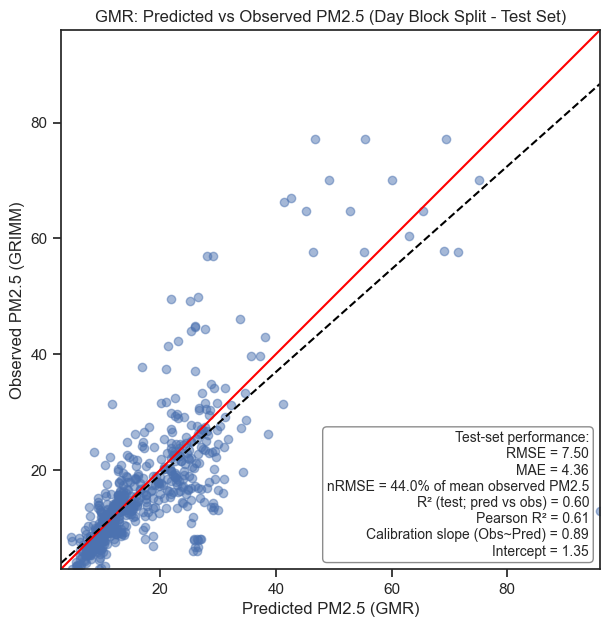

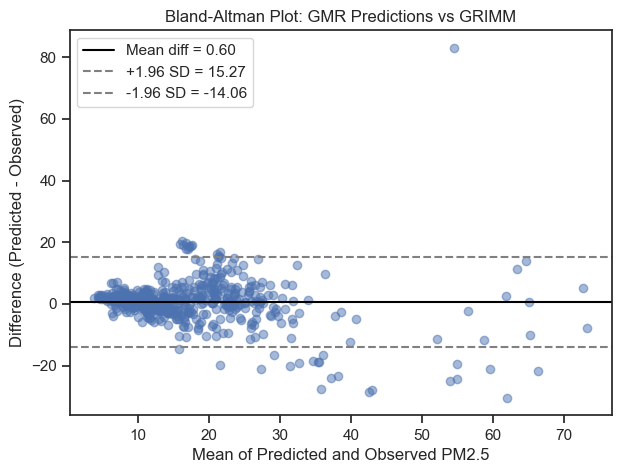

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression

# Build test results dataframe
test_results = test_.copy()
test_results["pred_gmr"] = y_pred  # assumes y_pred is your GMR prediction from the test set

# Metrics
rmse_val = np.sqrt(mean_squared_error(test_results["grimm_pm25"], test_results["pred_gmr"]))
mae_val = mean_absolute_error(test_results["grimm_pm25"], test_results["pred_gmr"])
rsq_val = r2_score(test_results["grimm_pm25"], test_results["pred_gmr"])

# Optional: Pearson R^2 if you want to match what you were doing in R
pearson_r2 = np.corrcoef(test_results["grimm_pm25"], test_results["pred_gmr"])[0, 1] ** 2

# Normalized RMSE (% of mean observed PM2.5)
mean_obs = test_results["grimm_pm25"].mean()
nrmse_pct = 100 * rmse_val / mean_obs

print('Normalized RMSE percent: ', nrmse_pct)


# Calibration: observed ~ predicted
cal_model = LinearRegression()
X_cal = test_results[["pred_gmr"]]
y_cal = test_results["grimm_pm25"]
cal_model.fit(X_cal, y_cal)

cal_int = cal_model.intercept_
cal_slope = cal_model.coef_[0]

# Shared axis limits
lims = [
    min(test_results["grimm_pm25"].min(), test_results["pred_gmr"].min()),
    max(test_results["grimm_pm25"].max(), test_results["pred_gmr"].max())
]

# Predicted vs observed plot
plt.figure(figsize=(7, 7))

plt.scatter(
    test_results["pred_gmr"],
    test_results["grimm_pm25"],
    alpha=0.5
)

# 1:1 line
plt.plot(lims, lims, color="red")

# fitted calibration line
x_line = np.linspace(lims[0], lims[1], 200)
y_line = cal_int + cal_slope * x_line
plt.plot(x_line, y_line, linestyle="dashed", color="black")

plt.xlim(lims)
plt.ylim(lims)
plt.gca().set_aspect("equal", adjustable="box")

plt.title("GMR: Predicted vs Observed PM2.5 (Day Block Split - Test Set)")
plt.xlabel("Predicted PM2.5 (GMR)")
plt.ylabel("Observed PM2.5 (GRIMM)")

caption_text = (
    f"Test-set performance:\n"
    f"RMSE = {rmse_val:.2f}\n"
    f"MAE = {mae_val:.2f}\n"
    f"nRMSE = {nrmse_pct:.1f}% of mean observed PM2.5\n"
    f"R² (test; pred vs obs) = {rsq_val:.2f}\n"
    f"Pearson R² = {pearson_r2:.2f}\n"
    f"Calibration slope (Obs~Pred) = {cal_slope:.2f}\n"
    f"Intercept = {cal_int:.2f}"
)

plt.text(
    0.98, 0.02,
    caption_text,
    transform=plt.gca().transAxes,
    ha="right",
    va="bottom",
    fontsize=10,
    bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="gray", alpha=0.9)
)

plt.show()

# -----------------------------
# Bland-Altman plot
# -----------------------------
test_results["ba_mean"] = (test_results["pred_gmr"] + test_results["grimm_pm25"]) / 2
test_results["ba_diff"] = test_results["pred_gmr"] - test_results["grimm_pm25"]

mean_diff = test_results["ba_diff"].mean()
sd_diff = test_results["ba_diff"].std()

loa_upper = mean_diff + 1.96 * sd_diff
loa_lower = mean_diff - 1.96 * sd_diff

plt.figure(figsize=(7, 5))

plt.scatter(
    test_results["ba_mean"],
    test_results["ba_diff"],
    alpha=0.5
)

plt.axhline(mean_diff, linestyle="-", color="black", label=f"Mean diff = {mean_diff:.2f}")
plt.axhline(loa_upper, linestyle="dashed", color="gray", label=f"+1.96 SD = {loa_upper:.2f}")
plt.axhline(loa_lower, linestyle="dashed", color="gray", label=f"-1.96 SD = {loa_lower:.2f}")

plt.title("Bland-Altman Plot: GMR Predictions vs GRIMM")
plt.xlabel("Mean of Predicted and Observed PM2.5")
plt.ylabel("Difference (Predicted - Observed)")

plt.legend()
plt.show()

### missing input analysis 

In [14]:
# Missing RH
Y_noRH = gmm.predict(
    np.array([0, 1, 3, 4, 5]),
    test_[["mod_pm25", "mod_temp", "sin_hour", "cos_hour", "season_binary"]].to_numpy()
)
y_pred = Y_noRH[:, 1]

y_true = test_["grimm_pm25"].to_numpy()

print('conditional GMR prediction with missing RH')
print('R2: ', r2_score(y_true, y_pred))
print('MAE: ', mean_absolute_error(y_true, y_pred))
print('Bias: ', n_bias(y_pred, y_true))
print('cvMAE: ', cvMAE(y_pred, y_true))
print('MNB: ', mnbias(y_pred, y_true))


# Missing temperature
Y_notemp = gmm.predict(
    np.array([0, 2, 3, 4, 5]),
    test_[["mod_pm25", "mod_rh", "sin_hour", "cos_hour", "season_binary"]].to_numpy()
)
y_pred = Y_notemp[:, 1]

print('\nconditional GMR prediction wit missing temperature')
print('R2: ', r2_score(y_true, y_pred))
print('MAE: ', mean_absolute_error(y_true, y_pred))
print('Bias: ', n_bias(y_pred, y_true))
print('cvMAE: ', cvMAE(y_pred, y_true))
print('MNB: ', mnbias(y_pred, y_true))


# Missing temperature and RH
Y_justMOD = gmm.predict(
    np.array([0, 3, 4, 5]),
    test_[["mod_pm25", "sin_hour", "cos_hour", "season_binary"]].to_numpy()
)
y_pred = Y_justMOD[:, 2]

print('\nconditional GMR prediction with missing temperature and RH')
print('R2: ', r2_score(y_true, y_pred))
print('MAE: ', mean_absolute_error(y_true, y_pred))
print('Bias: ', n_bias(y_pred, y_true))
print('cvMAE: ', cvMAE(y_pred, y_true))
print('MNB: ', mnbias(y_pred, y_true))

conditional GMR prediction with missing RH
R2:  0.5232427315518704
MAE:  4.68718767774085
Bias:  0.8441239084899961
cvMAE:  0.2709275602889845
MNB:  0.049489748916468825

conditional GMR prediction wit missing temperature
R2:  0.5827292640141726
MAE:  4.427073458719926
Bias:  0.5456207997791139
cvMAE:  0.25604132966689874
MNB:  0.031988948675763365

conditional GMR prediction with missing temperature and RH
R2:  0.5190527143782526
MAE:  4.68208409543786
Bias:  0.8018107074503217
cvMAE:  0.2698996904653688
MNB:  0.0470089878880891


## GMR figures

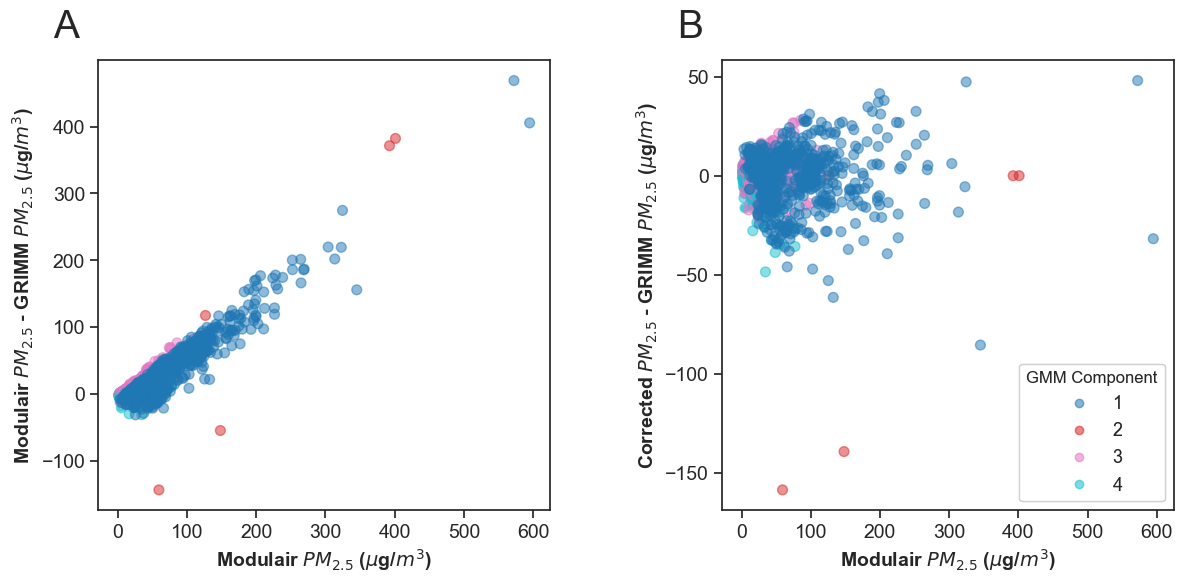

In [15]:
# GMR Figures

fit_cols = ["mod_pm25", "mod_temp", "mod_rh", "sin_hour", "cos_hour", "season_binary", "grimm_pm25"]

# use cleaned TRAINING data so dimensions match what gmm expects
plot_data = train_[fit_cols].dropna().copy()

# get array of responsibilities based on ORIGINAL GMM
# each row gives probabilities of belonging to each mixture component
probs = gmm.to_responsibilities(plot_data.to_numpy())
labels = np.argmax(probs, axis=1)

# create size object to visualize responsibilities more easily
size = 50 * probs.max(1) ** 3
legend_values = labels + 1

# get array of raw biases to plot
bias = plot_data["mod_pm25"].to_numpy() - plot_data["grimm_pm25"].to_numpy()

# regress entire training data set using all predictors except outcome
Y2 = gmm.predict(
    np.array([0, 1, 2, 3, 4, 5]),
    plot_data[["mod_pm25", "mod_temp", "mod_rh", "sin_hour", "cos_hour", "season_binary"]].to_numpy()
).ravel()

modelbias = Y2 - plot_data["grimm_pm25"].to_numpy()

# set color map
colors = plt.cm.get_cmap("tab10", best_n)

sns.set_style("ticks", {"xtick.major.size": 7, "ytick.major.size": 7})
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

ax1.scatter(
    plot_data["mod_pm25"],
    bias,
    c=legend_values,
    cmap=colors,
    s=size,
    alpha=0.5
)
ax1.tick_params(axis="x", labelsize=14)
ax1.tick_params(axis="y", labelsize=14)
ax1.set_xlabel('Modulair $PM_{2.5}$ ($\\mu$g/$m^3$)', fontweight="bold", fontsize=14)
ax1.set_ylabel('Modulair $PM_{2.5}$ - GRIMM $PM_{2.5}$ ($\\mu$g/$m^3$)', fontweight="bold", fontsize=14)
ax1.text(-0.1, 1.05, "A", transform=ax1.transAxes, size=28)

scatterb = ax2.scatter(
    plot_data["mod_pm25"],
    modelbias,
    c=legend_values,
    cmap=colors,
    s=size,
    alpha=0.5
)
ax2.tick_params(axis="x", labelsize=14)
ax2.tick_params(axis="y", labelsize=14)
ax2.set_xlabel('Modulair $PM_{2.5}$ ($\\mu$g/$m^3$)', fontweight="bold", fontsize=14)
ax2.set_ylabel('Corrected $PM_{2.5}$ - GRIMM $PM_{2.5}$ ($\\mu$g/$m^3$)', fontweight="bold", fontsize=14)
ax2.text(-0.1, 1.05, "B", transform=ax2.transAxes, size=28)

legend2 = ax2.legend(
    *scatterb.legend_elements(),
    loc="best",
    title="GMM Component",
    fontsize=13
)
ax2.add_artist(legend2)
plt.setp(legend2.get_title(), fontsize=12)

fig.tight_layout(w_pad=5)
plt.show()

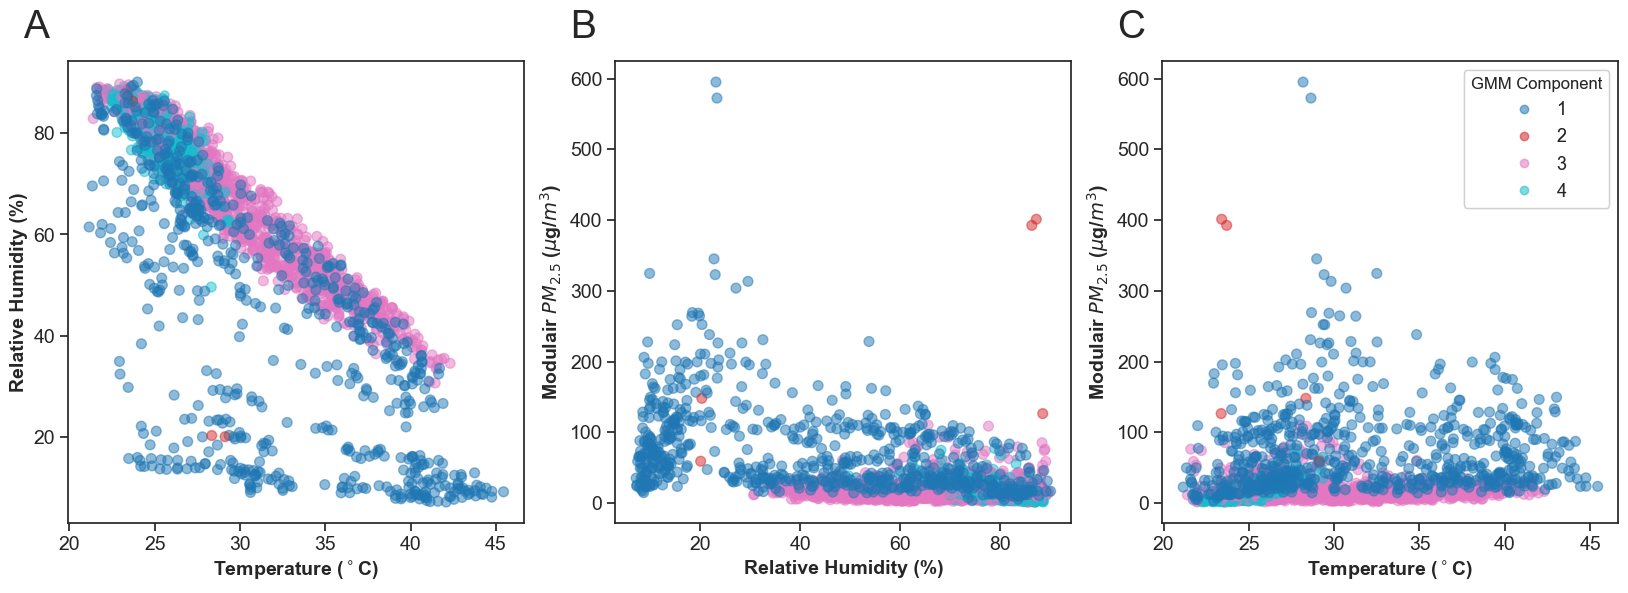

In [16]:
sns.set_style("ticks", {"xtick.major.size": 7, "ytick.major.size": 7})
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(20, 6))

ax1.scatter(
    plot_data["mod_temp"],
    plot_data["mod_rh"],
    c=legend_values,
    cmap=colors,
    s=size,
    alpha=0.5
)
ax1.tick_params(axis="x", labelsize=14)
ax1.tick_params(axis="y", labelsize=14)
ax1.set_xlabel('Temperature ($^\\circ$C)', fontweight="bold", fontsize=14)
ax1.set_ylabel('Relative Humidity (%)', fontweight="bold", fontsize=14)
ax1.text(-0.1, 1.05, "A", transform=ax1.transAxes, size=28)

ax2.scatter(
    plot_data["mod_rh"],
    plot_data["mod_pm25"],
    c=legend_values,
    cmap=colors,
    s=size,
    alpha=0.5
)
ax2.tick_params(axis="x", labelsize=14)
ax2.tick_params(axis="y", labelsize=14)
ax2.set_ylabel('Modulair $PM_{2.5}$ ($\\mu$g/$m^3$)', fontweight="bold", fontsize=14)
ax2.set_xlabel('Relative Humidity (%)', fontweight="bold", fontsize=14)
ax2.text(-0.1, 1.05, "B", transform=ax2.transAxes, size=28)

scatter3 = ax3.scatter(
    plot_data["mod_temp"],
    plot_data["mod_pm25"],
    c=legend_values,
    cmap=colors,
    s=size,
    alpha=0.5
)
ax3.tick_params(axis="x", labelsize=14)
ax3.tick_params(axis="y", labelsize=14)
ax3.set_ylabel('Modulair $PM_{2.5}$ ($\\mu$g/$m^3$)', fontweight="bold", fontsize=14)
ax3.set_xlabel('Temperature ($^\\circ$C)', fontweight="bold", fontsize=14)
ax3.text(-0.1, 1.05, "C", transform=ax3.transAxes, size=28)

legend3 = ax3.legend(
    *scatter3.legend_elements(),
    loc="best",
    title="GMM Component",
    fontsize=13
)
ax3.add_artist(legend3)
plt.setp(legend3.get_title(), fontsize=12)

plt.show()

### Save model (saved the one with hour and season)

In [17]:
import pickle
from pathlib import Path

fit_cols = ["mod_pm25", "mod_temp", "mod_rh", "sin_hour", "cos_hour", "season_binary", "grimm_pm25"]
x_cols = ["mod_pm25", "mod_temp", "mod_rh", "sin_hour", "cos_hour", "season_binary"]

full_calibration = model_data_dayblock[fit_cols].dropna().copy()

gmm_final = GMM(n_components=4, random_state=11)
gmm_final.from_samples(full_calibration.to_numpy())

# save fitted model
model_outpath = Path("/Users/lewiswhite/CHAP_columbia/QuantAQ_ghana/data/calibration/gmr_dayblock_final_pm25.pkl")
with open(model_outpath, "wb") as f:
    pickle.dump(gmm_final, f)

print(f"Saved model to: {model_outpath}")

Saved model to: /Users/lewiswhite/CHAP_columbia/QuantAQ_ghana/data/calibration/gmr_dayblock_final_pm25.pkl


#### Load and prepare sample of Modulair data for checks

In [22]:
import numpy as np
import pandas as pd

# INSERT PATHS
pm25_1 = pd.read_csv("/Users/lewiswhite/CHAP_columbia/QuantAQ_ghana/data/pm/summarized/pm25_community_hourly_20230815_20240816.csv")
pm25_2 = pd.read_csv("/Users/lewiswhite/CHAP_columbia/QuantAQ_ghana/data/pm/summarized/pm25_community_hourly_20241031_20250901.csv")
temp_1 = pd.read_csv("/Users/lewiswhite/CHAP_columbia/QuantAQ_ghana/data/weather/summarized/temp_hourly_20230815-20240820.csv")
temp_2 = pd.read_csv("/Users/lewiswhite/CHAP_columbia/QuantAQ_ghana/data/weather/summarized/temp_hourly_20241031-20250901.csv")
rh_1   = pd.read_csv("/Users/lewiswhite/CHAP_columbia/QuantAQ_ghana/data/weather/summarized/rh_hourly_20230815-20240820.csv")
rh_2   = pd.read_csv("/Users/lewiswhite/CHAP_columbia/QuantAQ_ghana/data/weather/summarized/rh_hourly_20241031-20250901.csv")

pm25 = pd.concat([pm25_1, pm25_2], ignore_index=True)
temp = pd.concat([temp_1, temp_2], ignore_index=True)
rh   = pd.concat([rh_1, rh_2], ignore_index=True)

pm25 = pm25.loc[pm25["mean_pm25"].notna()].copy()
temp = temp.loc[temp["mean_met_temp"].notna()].copy()
rh   = rh.loc[rh["mean_met_rh"].notna()].copy()

# drop extra columns if present
for df, cols in [
    (pm25, ["n_minute_obs", "n_active", "fleet_average_pm25"]),
    (temp, ["n_minute_obs", "n_active", "fleet_average_met_temp"]),
    (rh,   ["n_minute_obs", "n_active", "fleet_average_met_rh"]),
]:
    drop_cols = [c for c in cols if c in df.columns]
    df.drop(columns=drop_cols, inplace=True)

modulair_full = (
    pm25.merge(temp, on=["monitor", "date", "hour"], how="outer")
        .merge(rh, on=["monitor", "date", "hour"], how="outer")
)

modulair_full["date"] = pd.to_datetime(modulair_full["date"])
modulair_full["date_hour"] = pd.to_datetime(
    modulair_full["date"].dt.strftime("%Y-%m-%d") + " " + modulair_full["hour"].astype(int).astype(str) + ":00:00",
    utc=True
)

modulair_full = modulair_full.rename(columns={
    "mean_pm25": "mod_pm25",
    "mean_met_temp": "mod_temp",
    "mean_met_rh": "mod_rh"
})

modulair_full["month"] = modulair_full["date"].dt.month
modulair_full["season_binary"] = np.where(modulair_full["month"].isin([12, 1, 2]), 1, 0)
modulair_full["sin_hour"] = np.sin(2 * np.pi * modulair_full["hour"] / 24)
modulair_full["cos_hour"] = np.cos(2 * np.pi * modulair_full["hour"] / 24)

# require predictors used by GMR
pred_cols = ["mod_pm25", "mod_temp", "mod_rh", "sin_hour", "cos_hour", "season_binary"]
modulair_apply = modulair_full.dropna(subset=pred_cols).copy()

print(modulair_apply.shape)
modulair_apply.head()

(455757, 11)


,monitor,date,hour,mod_pm25,mod_temp,mod_rh,date_hour,month,season_binary,sin_hour,cos_hour
0,MOD-00077,2024-10-31,0.0,42.607167,25.703333,82.776667,2024-10-31 00:00:00+00:00,10,0,0.000000,1.000000
1,MOD-00077,2024-10-31,1.0,29.868667,25.303333,83.910000,2024-10-31 01:00:00+00:00,10,0,0.258819,0.965926
2,MOD-00077,2024-10-31,2.0,27.362000,24.958333,85.163333,2024-10-31 02:00:00+00:00,10,0,0.500000,0.866025
3,MOD-00077,2024-10-31,3.0,37.985000,24.740000,86.226667,2024-10-31 03:00:00+00:00,10,0,0.707107,0.707107
4,MOD-00077,2024-10-31,4.0,30.867667,24.708333,86.286667,2024-10-31 04:00:00+00:00,10,0,0.866025,0.500000


#### Apply saved GMR model

In [23]:
with open("/Users/lewiswhite/CHAP_columbia/QuantAQ_ghana/data/calibration/gmr_dayblock_final.pkl", "rb") as f:
    gmm_loaded = pickle.load(f)

X_full = modulair_apply[["mod_pm25", "mod_temp", "mod_rh", "sin_hour", "cos_hour", "season_binary"]].to_numpy()

Y_full = gmm_loaded.predict(
    np.array([0, 1, 2, 3, 4, 5]),
    X_full
).ravel()

modulair_apply["pm25_fem_gmr"] = np.maximum(Y_full, 0)
modulair_apply["delta_gmr"] = modulair_apply["pm25_fem_gmr"] - modulair_apply["mod_pm25"]
modulair_apply["ratio_gmr"] = np.where(
    modulair_apply["mod_pm25"] > 0,
    modulair_apply["pm25_fem_gmr"] / modulair_apply["mod_pm25"],
    np.nan
)

modulair_apply.head()

,monitor,date,hour,mod_pm25,mod_temp,mod_rh,date_hour,month,season_binary,sin_hour,cos_hour,pm25_fem_gmr,delta_gmr,ratio_gmr
0,MOD-00077,2024-10-31,0.0,42.607167,25.703333,82.776667,2024-10-31 00:00:00+00:00,10,0,0.000000,1.000000,25.589120,-17.018047,0.600583
1,MOD-00077,2024-10-31,1.0,29.868667,25.303333,83.910000,2024-10-31 01:00:00+00:00,10,0,0.258819,0.965926,22.305059,-7.563607,0.746771
2,MOD-00077,2024-10-31,2.0,27.362000,24.958333,85.163333,2024-10-31 02:00:00+00:00,10,0,0.500000,0.866025,21.399114,-5.962886,0.782074
3,MOD-00077,2024-10-31,3.0,37.985000,24.740000,86.226667,2024-10-31 03:00:00+00:00,10,0,0.707107,0.707107,20.785413,-17.199587,0.547201
4,MOD-00077,2024-10-31,4.0,30.867667,24.708333,86.286667,2024-10-31 04:00:00+00:00,10,0,0.866025,0.500000,19.303266,-11.564400,0.625356


#### Raw vs calibrated plot

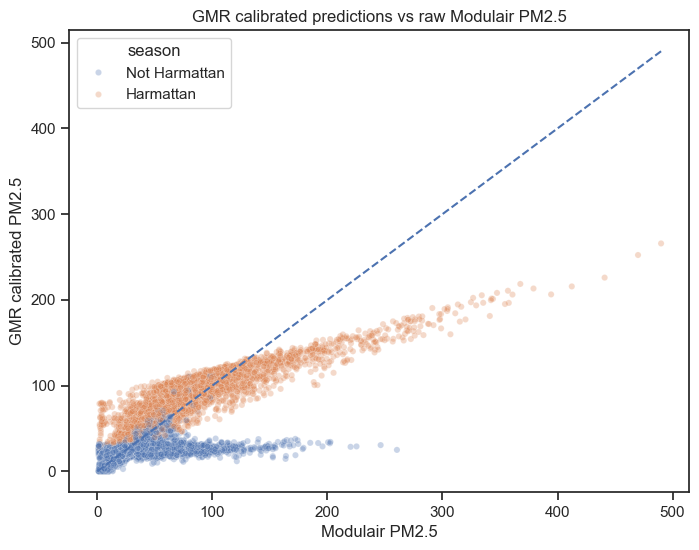

In [24]:
plot_df = modulair_apply.sample(n=min(10000, len(modulair_apply)), random_state=123).copy()
plot_df["season"] = np.where(plot_df["season_binary"] == 1, "Harmattan", "Not Harmattan")

plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_df, x="mod_pm25", y="pm25_fem_gmr", hue="season", alpha=0.3, s=20)
lims = [
    min(plot_df["mod_pm25"].min(), plot_df["pm25_fem_gmr"].min()),
    max(plot_df["mod_pm25"].max(), plot_df["pm25_fem_gmr"].max())
]
plt.plot(lims, lims, linestyle="--")
plt.xlabel("Modulair PM2.5")
plt.ylabel("GMR calibrated PM2.5")
plt.title("GMR calibrated predictions vs raw Modulair PM2.5")
plt.show()

#### Calibration change by monitor

In [25]:
monitor_summary = (
    modulair_apply.groupby("monitor")
    .agg(
        n=("mod_pm25", "size"),
        mean_raw=("mod_pm25", "mean"),
        mean_gmr=("pm25_fem_gmr", "mean"),
        mean_delta_gmr=("delta_gmr", "mean"),
        median_ratio_gmr=("ratio_gmr", "median")
    )
    .reset_index()
)

# round columns
monitor_summary = monitor_summary.round({
    "mean_raw": 2,
    "mean_gmr": 2,
    "mean_delta_gmr": 2,
    "median_ratio_gmr": 2
})

# sort
monitor_summary = monitor_summary.sort_values(
    "mean_delta_gmr", key=np.abs, ascending=False
)

monitor_summary

,monitor,n,mean_raw,mean_gmr,mean_delta_gmr,median_ratio_gmr
13,MOD-PM-00881,7422,81.54,44.37,-37.18,0.64
0,MOD-00077,885,87.16,50.53,-36.63,0.66
7,MOD-PM-00872,795,88.04,63.65,-24.38,0.83
6,MOD-PM-00871,2253,83.92,71.17,-12.75,0.99
19,MOD-PM-00887,4965,49.51,37.84,-11.67,0.93
...,...,...,...,...,...,...
8,MOD-PM-00876,11252,35.38,34.92,-0.46,1.00
60,MOD-PM-01088,3831,49.14,49.59,0.45,1.04
59,MOD-PM-01087,3251,59.17,59.57,0.40,1.03
50,MOD-PM-01078,5163,42.79,42.94,0.15,1.00


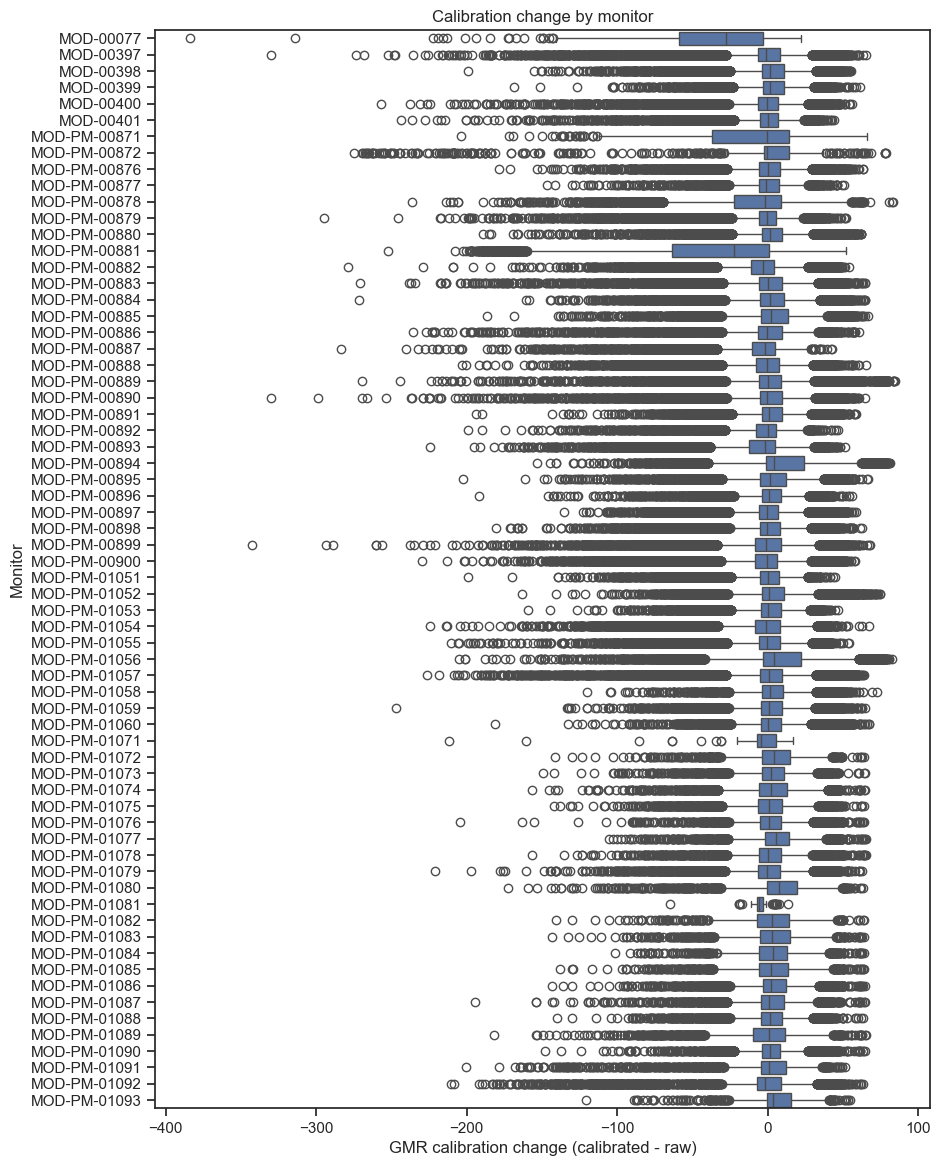

In [26]:
plt.figure(figsize=(10, 14))
sns.boxplot(data=modulair_apply, x="delta_gmr", y="monitor")
plt.xlabel("GMR calibration change (calibrated - raw)")
plt.ylabel("Monitor")
plt.title("Calibration change by monitor")
plt.show()

#### Calibration change vs RH

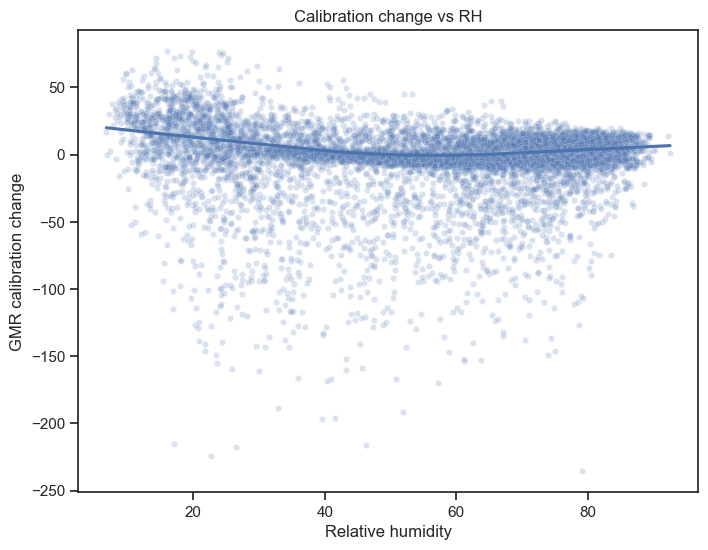

In [27]:
plot_df = modulair_apply.sample(n=min(10000, len(modulair_apply)), random_state=123)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_df, x="mod_rh", y="delta_gmr", alpha=0.2, s=20)
sns.regplot(data=plot_df, x="mod_rh", y="delta_gmr", scatter=False, lowess=True)
plt.xlabel("Relative humidity")
plt.ylabel("GMR calibration change")
plt.title("Calibration change vs RH")
plt.show()

#### Calibration change vs temperature

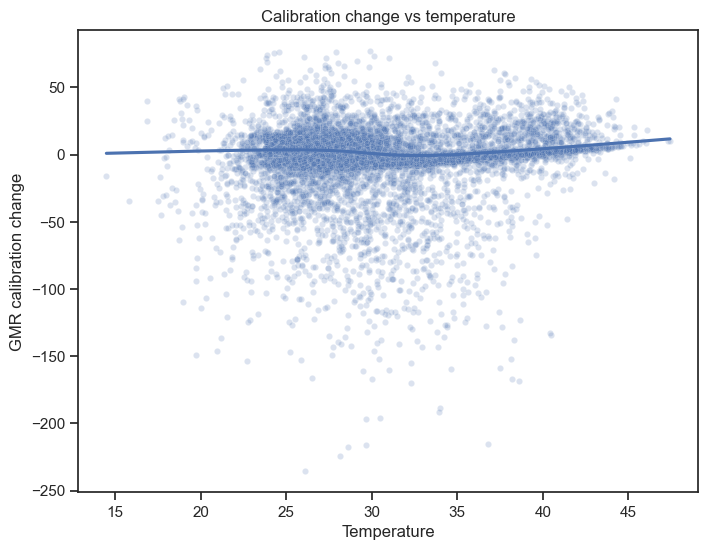

In [28]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=plot_df, x="mod_temp", y="delta_gmr", alpha=0.2, s=20)
sns.regplot(data=plot_df, x="mod_temp", y="delta_gmr", scatter=False, lowess=True)
plt.xlabel("Temperature")
plt.ylabel("GMR calibration change")
plt.title("Calibration change vs temperature")
plt.show()